**1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

In [2]:
try:
  df = pd.read_csv("../data/raw/video_game_sales.csv")
  print("Dataset loaded successfully.")
except FileNotFoundError:
  print("File not found. Please check the file path.")

Dataset loaded successfully.


**3. Jumlah Baris dan Kolom Dataset**

In [3]:
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]
nama_kolom = [col for col in df.columns]
print(f"Jumlah baris: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")
print(f"Nama kolom: {nama_kolom}")

Jumlah baris: 16598
Jumlah kolom: 11
Nama kolom: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


**4. Lima Baris Data Teratas**

In [4]:
print(df.head())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


**5. Ringkasan Dataset**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


**6. Ringkasan Statistik Data Numerik**

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.0,8300.605254,4791.853933,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.0,2006.406443,5.828981,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


**7. Cek Apakah Ada Missing Value**

In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**8. Cek Apakah Ada Duplicate Value**

In [8]:
df.duplicated().sum()

np.int64(0)

**9. Grafik Top 10 Penjualan Global Genre Game**

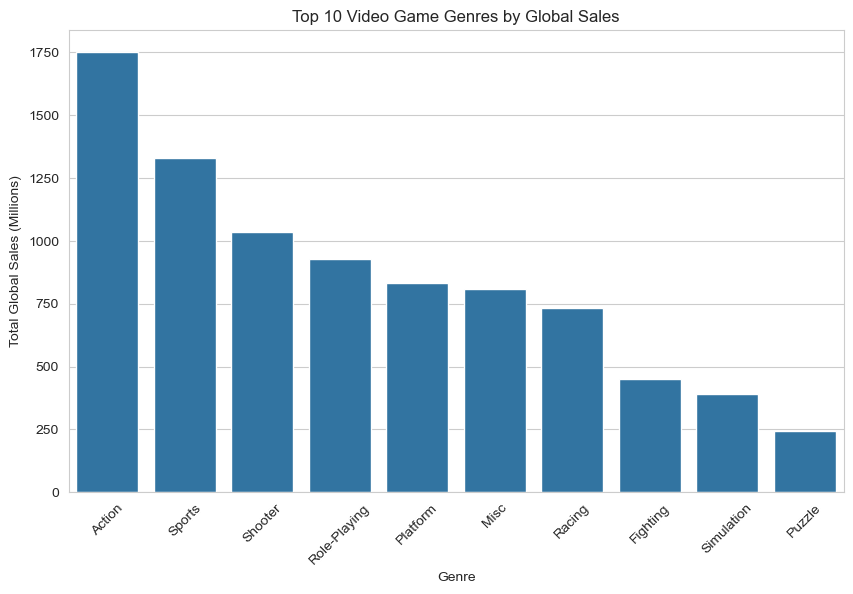

In [11]:
sns.set_style("whitegrid")
genre_sales = (
    df.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_sales,
    x='Genre',
    y='Global_Sales'
)

plt.title("Top 10 Video Game Genres by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales (Millions)")

plt.xticks(rotation=45)

plt.show()

**10. Grafik Tren Penjualan Video Game Berdasarkan Tahun Rilis**

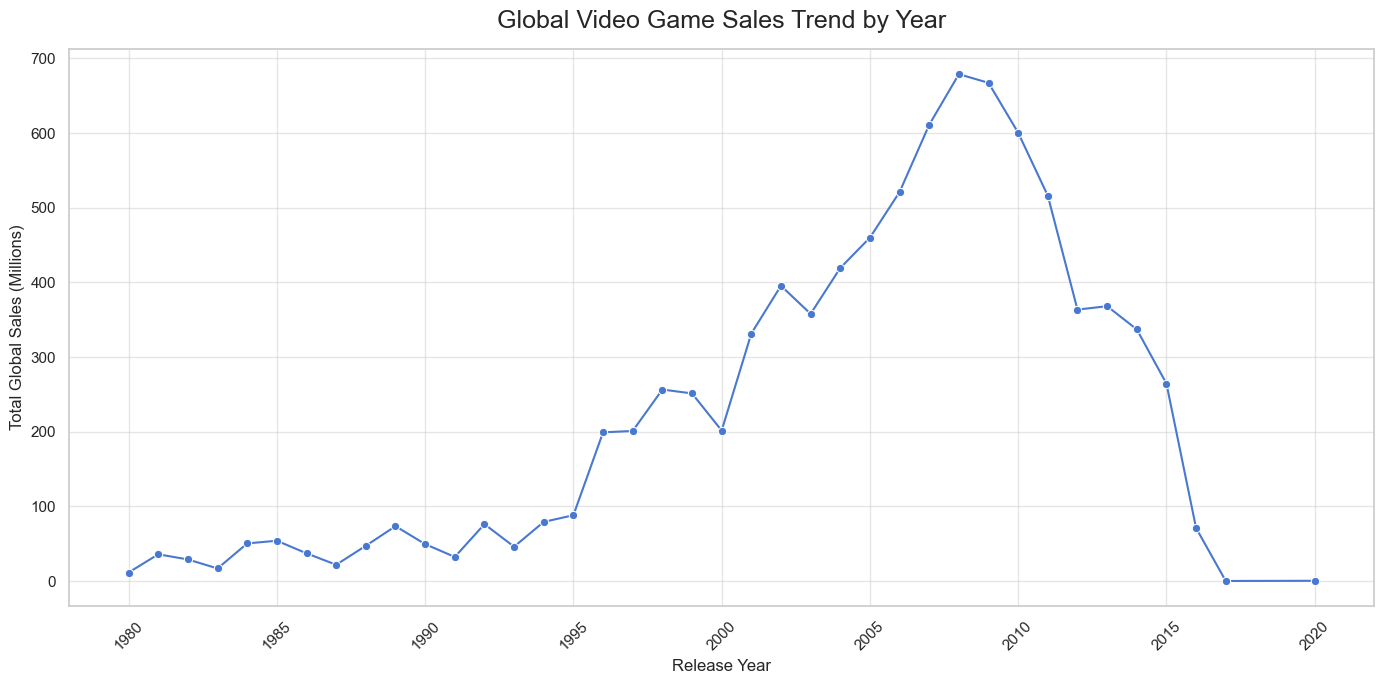

In [19]:
sns.set_style("whitegrid")

df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

yearly_sales = (
    df.groupby('Year')['Global_Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=yearly_sales,
    x='Year',
    y='Global_Sales',
    marker='o'
)

plt.title(
    "Global Video Game Sales Trend by Year",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Release Year",
    fontsize=12
)

plt.ylabel(
    "Total Global Sales (Millions)",
    fontsize=12
)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()